# Multistart Optimization and Profile Likelihood with ParmEst

Parameter estimation problems are often **nonconvex**, meaning that the objective function  
$g(\boldsymbol{x}, \boldsymbol{y};\boldsymbol{\theta})$ may contain multiple local minima.  
As a result, the solution obtained by a nonlinear optimization solver can depend strongly  
on the initial guess for $\boldsymbol{\theta}$.

Multistart optimization is a practical strategy to address this challenge. Instead of solving  
the problem once from a single initial point, we solve it multiple times from different  
initializations and compare the resulting solutions.

This approach helps:
- Increase the likelihood of identifying a **global or near-global optimum**
- Assess the **robustness** of parameter estimates
- Explore the **structure of the objective landscape**

### Import the necessary packages

In [1]:
import sys
import logging
import pandas as pd
import numpy as np

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_multistart_sampling,
    plot_profile_likelihood,
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Load the experimental data

In [2]:
# load experimental data
if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)

# store in custom data class 
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Multistart in ParmEst

The multistart functionality in `ParmEst` automates this process by generating multiple  
initial guesses for $\boldsymbol{\theta}$ within user-defined bounds and solving the  
parameter estimation problem repeatedly.

Initial points are sampled between predefined lower and upper bounds using one of the following methods:

- **Uniform random sampling**
- **Latin hypercube sampling (LHS)**
- **Sobol sequence sampling**

Each sampled point defines a new initialization of $\boldsymbol{\theta}$, and the optimization  
problem is solved independently for each case.

### TC Lab parameter estimation problem statement

As stated [previously](./parmest.ipynb): 

We seek to estimate the heat transfer parameters, $C_p^H$, $C_p^S$, $U_a$, and $U_b$ from 
the sensor temperature data outlined above.

The predictions of the sensor temperature are obtained from the following model structure:

$$
\begin{align*}
C_p^H \frac{dT_H}{dt} & = U_a (T_{amb} - T_H) + U_c (T_S - T_H) + \alpha P u(t)\\
C_p^S \frac{dT_S}{dt} & = - U_b (T_S - T_H)
\end{align*}
$$
$$
\begin{align*}
\text{control input data}\qquad u(t_i) & = \bar{u}_{i}, \forall i \in \mathcal{T}
\\
\text{initial condition}\qquad T_H(t_0) & = T_{amb} \\
\text{initial condition}\qquad T_S(t_0) & = T_{amb}
\end{align*}
$$

where $T_{H}$ and $T_{S}$ are the heater and sensor temperatures in $^{\circ} \text{C}$, 
respectively, $T_{amb}$ is the ambient temperature in $^{\circ} \text{C}$, $C_p^H$ and 
$C_p^S$ are the heat capacity of the heater and sensor in $\text{J}/^{\circ} \text{C}$, 
respectively, $U_{a}$ and $U_{b}$ are the heat transfer coefficients from the heater to the 
sensor and the sensor to ambient (in $\text{W}/^{\circ} \text{C}$), respectively, $P$ is the 
maximum power limit in $\text{bit}$, $u$ is the heater power in $\%$, and $\alpha$ is 
constant that converts the unit of $P u(t)$ into $\text{W}$.


The difference here is we are using sampling techniques to automate the process of searching 
from multiple initial values of the estimated heat transfer parameters.

In [3]:
# # Import parmest
import pyomo.contrib.parmest.parmest as parmest

# Set logging level to ERROR to suppress solver output and warnings from parmest
logging.basicConfig(level=logging.ERROR)

parmest_logger = logging.getLogger("pyomo.contrib.parmest.parmest")
parmest_logger.setLevel(logging.ERROR)

In [4]:
# First, we define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

solver_options = {
                  'linear_solver': 'ma57', 
                  'max_iter': 1000
                  }


# Set some common options for all multistart estimation runs
common_multistart_options = {
    'n_restarts': 15,
    'seed': 532,
    'save_results': False,
}

In [5]:
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest_uniform = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', 
                         tee=True, solver_options=solver_options
                         )

results_df, best_theta_uniform, best_obj_uniform = pest_uniform.theta_est_multistart(
        multistart_sampling_method="uniform_random",
        n_restarts=common_multistart_options['n_restarts'],
        seed=common_multistart_options['seed'],
        save_results=common_multistart_options['save_results'],

)

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

Let's see how to access the regression results:

In [6]:
print("Estimated parameters:\n", best_theta_uniform)
print("Best objective function value:", best_obj_uniform)

Estimated parameters:
 {'Ua': 0.041705173357635135, 'Ub': 0.017064930852255578, 'inv_CpH': 0.1707011238132523, 'inv_CpS': 3.137848009988043}
Best objective function value: 53.773992845808294


In [7]:
# View snippet of results DataFrame from multistart estimation.
results_df.head(5)

,Ua,Ub,inv_CpH,inv_CpS,converged_Ua,converged_Ub,converged_inv_CpH,converged_inv_CpS,final objective,solver termination,solve_time
0,0.016529,0.013530,0.106616,9.039896,0.041705,0.016472,0.170306,3.258324,53.773993,optimal,1.881702
1,0.076425,0.026743,0.109221,5.283266,0.041705,0.016960,0.170631,3.158565,53.773993,optimal,1.535201
2,0.080409,0.034615,0.213525,5.525811,0.041705,0.017227,0.170810,3.106357,53.773993,optimal,1.551934
3,0.037777,0.018343,0.339094,3.618473,0.041705,0.017100,0.170725,3.130914,53.773993,optimal,1.477314
4,0.030780,0.040277,0.276454,1.167804,0.041705,0.017439,0.170953,3.065967,53.773993,optimal,1.582353


### Compare different multistart sampling methods 

In [8]:
# latin hypercube sampling
pest_lhs = parmest.Estimator([TC_Lab_sine_exp], obj_function='SSE', 
                             tee=False, solver_options=solver_options)

results_df_lhs, best_theta_lhs, best_obj_lhs = pest_lhs.theta_est_multistart(
        multistart_sampling_method="latin_hypercube",
        n_restarts=common_multistart_options['n_restarts'],
        seed=common_multistart_options['seed'],
        save_results=common_multistart_options['save_results'],

)

In [9]:
# Sobol sampling
pest_sobol = parmest.Estimator([TC_Lab_sine_exp], obj_function='SSE', 
                             tee=False, solver_options=solver_options)

results_df_sobol, best_theta_sobol, best_obj_sobol = pest_sobol.theta_est_multistart(
        multistart_sampling_method="sobol_sampling",
        n_restarts=common_multistart_options['n_restarts'],
        seed=common_multistart_options['seed'],
        save_results=common_multistart_options['save_results'],
)

In [10]:
theta_values_df = pd.DataFrame({
    'random_uniform': best_theta_uniform,
    'latin_hypercube': best_theta_lhs,
    'sobol_sampling': best_theta_sobol,
})
print("\nBest estimated parameters for different multistart sampling methods:\n", theta_values_df)

# Best objective function values for different multistart sampling methods
obj_values_df = pd.DataFrame({
    'random_uniform': best_obj_uniform,
    'latin_hypercube': best_obj_lhs,
    'sobol_sampling': best_obj_sobol,
}, index=['Best Objective Value'])
print("\nBest objective function values for different multistart sampling methods:\n", obj_values_df)


Best estimated parameters for different multistart sampling methods:
          random_uniform  latin_hypercube  sobol_sampling
Ua             0.041705         0.041705        0.041705
Ub             0.017065         0.017199        0.017104
inv_CpH        0.170701         0.170791        0.170727
inv_CpS        3.137848         3.111786        3.130236

Best objective function values for different multistart sampling methods:
                       random_uniform  latin_hypercube  sobol_sampling
Best Objective Value       53.773993        53.773993       53.773993


In [11]:
# Round the best objective function values to 4 decimal places for easier comparison

results_df['final objective'] = results_df['final objective'].round(6)
results_df_lhs['final objective'] = results_df_lhs['final objective'].round(6)
results_df_sobol['final objective'] = results_df_sobol['final objective'].round(6)  


# Compare the number of unique local minima found by different multistart sampling methods

num_unique_minima_uniform = len(results_df['final objective'].unique())
num_unique_minima_lhs = len(results_df_lhs['final objective'].unique())
num_unique_minima_sobol = len(results_df_sobol['final objective'].unique())

print("\nNumber of unique local minima found by different multistart sampling methods:")
print(f"Random Uniform Sampling: {num_unique_minima_uniform}")
print(f"Latin Hypercube Sampling: {num_unique_minima_lhs}")
print(f"Sobol Sampling: {num_unique_minima_sobol}")


Number of unique local minima found by different multistart sampling methods:
Random Uniform Sampling: 1
Latin Hypercube Sampling: 1
Sobol Sampling: 2


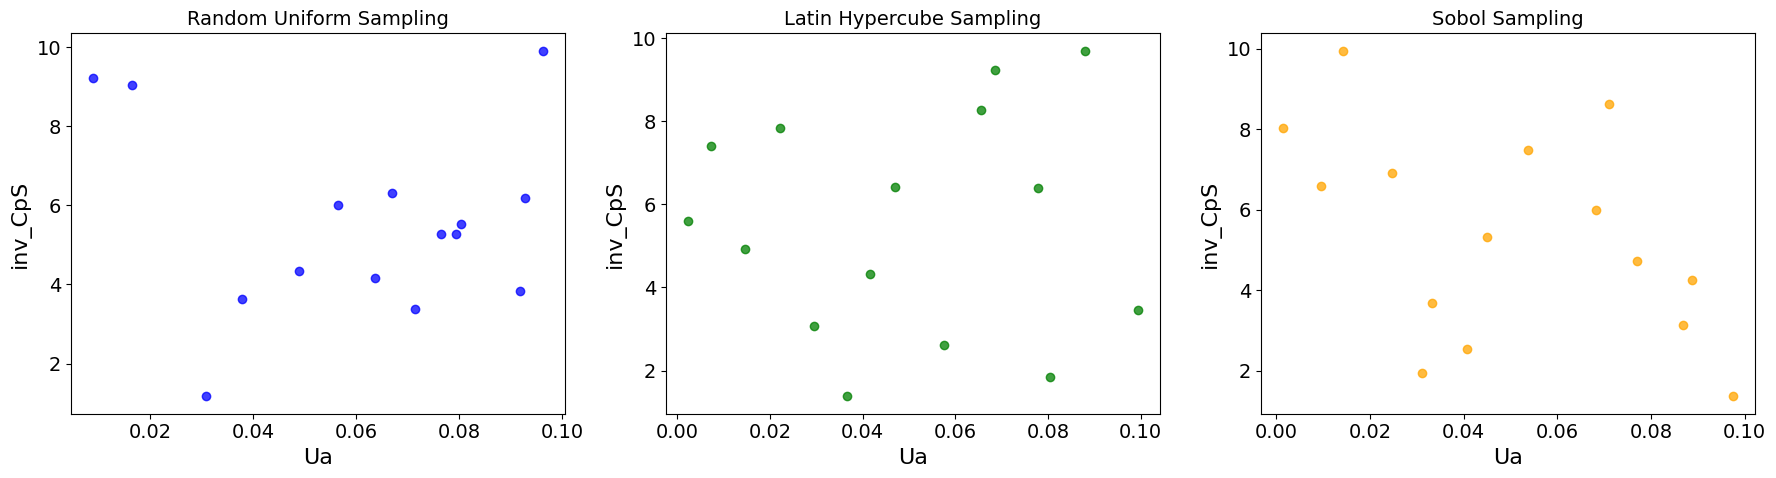

In [12]:
# Plot starting theta values for different multistart sampling methods
fig, axes = extract_multistart_sampling(results_df, results_df_lhs, results_df_sobol)

### Takeaways from the multistart optimization results

1. The different methods converge to different estimates, but the same objective value

   Differences in the parameters with same objective value points to a potential identifiability problem.

2. Stratified sampling techniques (LHS and Sobol) cover more area of the sample space

   Random uniform sampling, as shown above, can sample multiple points in same region.

## Profile likelihood in ParmEst

After estimating parameter values, it is important to assess whether those
parameters are supported by the available experimental data. In other words,
we would like to understand not only which parameter values minimize the
objective function, but also how much confidence we should have in those
values.

Two related concepts are especially important in parameter estimation:

1. **Identifiability**

    A parameter is identifiable if it can, in principle, be uniquely determined
    from ideal noise-free data and the specified model structure.

    Structural identifiability is a property of the model itself. If a parameter
    is structurally unidentifiable, then no amount of additional data from the
    same experimental setup will allow that parameter to be uniquely estimated.

2. **Estimability**

    A parameter is estimable if it can be reliably estimated from the available
    finite, noisy experimental data.

    Practical estimability depends on the model, the data, the measurement noise,
    and the experimental design. A parameter may be structurally identifiable but
    still difficult to estimate in practice if the data are not sufficiently
    informative.

In this workshop, we focus on practical estimability. We assume that the model
has been specified and that experimental data are available, and we ask whether
the data contain enough information to estimate each parameter with reasonable
confidence.

---

### Profile Likelihood

Profile likelihood is a useful tool for analyzing parameter estimability. The
main idea is to examine how much the objective function increases when one
parameter is fixed at values away from its estimated optimum, while all other
parameters are re-estimated.

Let $\hat{\boldsymbol{\theta}}$ be the parameter estimate obtained by solving

$$
   \hat{\boldsymbol{\theta}}
   =
   \arg\min_{\boldsymbol{\theta}}
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
$$

where $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$ is the parameter
estimation objective function.

For a parameter $\theta_j$, the profile likelihood is constructed by fixing
$\theta_j$ at a specified value and re-solving the parameter estimation problem
over the remaining parameters:

$$
   g_{\text{profile}}(\theta_j)
   =
   \min_{\boldsymbol{\theta}_{-j}}
   g(\boldsymbol{x}, \boldsymbol{y}; \theta_j, \boldsymbol{\theta}_{-j})
$$

where $\boldsymbol{\theta}_{-j}$ denotes the vector of all parameters except
$\theta_j$.

By repeating this calculation over a range of fixed values for $\theta_j$, we
obtain a profile that describes how sensitive the objective function is to
changes in that parameter.

---

### Interpreting Profile Likelihoods

The shape of the profile likelihood provides information about parameter
estimability.

If the profile likelihood increases sharply as $\theta_j$ moves away from its
estimated value, then the data strongly constrain that parameter. In this case,
$\theta_j$ is practically estimable.

If the profile likelihood is relatively flat over a wide range of values, then
many different values of $\theta_j$ provide similar agreement with the data. In
this case, $\theta_j$ may be practically non-estimable.

If the profile likelihood does not increase sufficiently in one or both
directions, then the data may only provide a one-sided bound or no meaningful
bound on the parameter.

Typical qualitative interpretations are:

- A **narrow profile** indicates that the parameter is well constrained by the data.
- A **wide profile** indicates that the parameter is weakly constrained by the data.
- A **flat profile** indicates that the parameter may be practically non-estimable.
- A **profile with a boundary** may indicate that the parameter is only bounded
  on one side or that the chosen parameter bounds affect the result.

In [13]:
# Do profile likelihood estimation to construct confidence intervals for the parameters. 
# This is a more robust method for constructing confidence intervals, 
# as it does not rely on the assumption of normality in the parameter estimates.

# Compute profile likelihood for both unknown parameters.
# Use a small grid for quick terminal runs.
profile_results = pest_sobol.profile_likelihood(
    profiled_theta=["Ua", "Ub", "inv_CpH", "inv_CpS"],
    obj_hat = best_obj_sobol,
    theta_hat = best_theta_sobol,
    n_grid=15,
    solver="ef_ipopt",
    warmstart="neighbor",
)

In [14]:
# Filter out runs that were not successful to focus on the successful ones for analysis
profiles = profile_results["profiles"]
profiles = profiles[profiles['success'] == True]
# Update the profile results to only include successful runs for 
# subsequent analysis and plotting
profile_results["profiles"] = profiles

# Display a compact summary table
print("\nProfile results (first 10 rows):")
print(
    profiles[
        [
            "profiled_theta",
            "theta_value",
            "lr_stat",
            "status",
        ]
    ].head(10)
)



Profile results (first 10 rows):
   profiled_theta  theta_value       lr_stat   status
4              Ua     0.028572  1.132894e+05  optimal
5              Ua     0.035715  2.461208e+04  optimal
6              Ua     0.041705  9.379164e-13  optimal
7              Ua     0.042858  8.810234e+02  optimal
8              Ua     0.050001  3.867391e+04  optimal
9              Ua     0.057143  1.141493e+05  optimal
10             Ua     0.064286  2.064041e+05  optimal
11             Ua     0.071429  3.024475e+05  optimal
12             Ua     0.078572  3.962728e+05  optimal
13             Ua     0.085714  4.852341e+05  optimal


Chi-squared threshold for 95% confidence interval: 3.8415


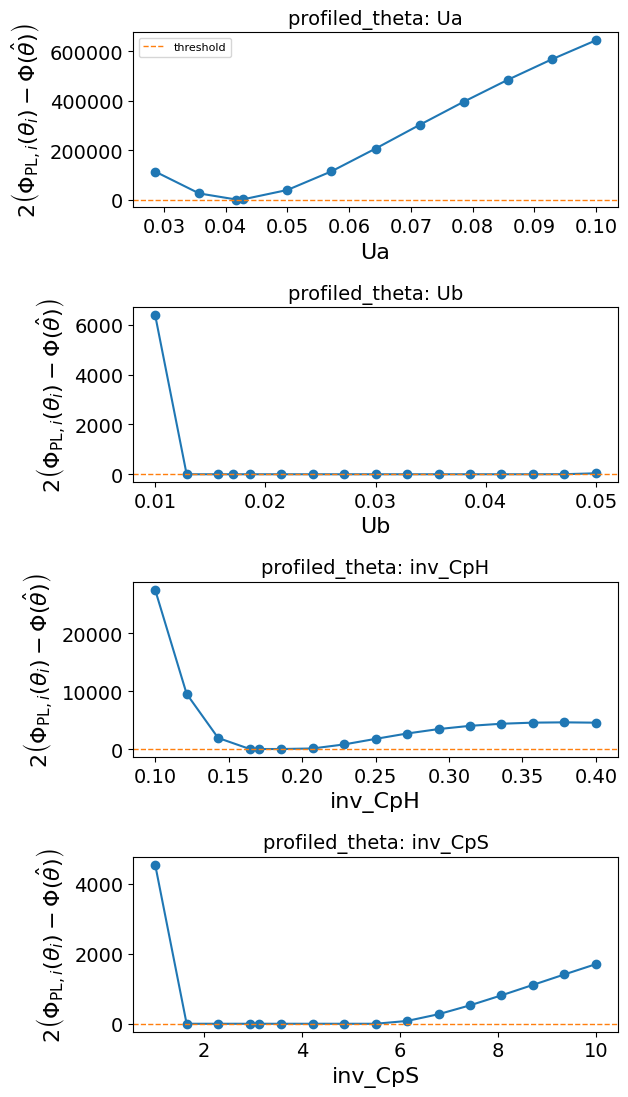

In [15]:
# Plot profile curves to visualize profile likelihood for each parameter.

# ylims = [(0, 100), (0, 100), (0, 100), (0, 100)]

fig, axes = plot_profile_likelihood(
    profile_results, alpha=0.95, 
    # ylims=ylims
)


## Activity: Discuss profile likelihood results above with a neighbor

Take 2 minutes. From the profile likelihood results:

- Which parameter(s) are estimable?
- Which parameter(s) are inestimable?
- What are possible next steps to improve the estimability?

(Optional): Uncomment and adjust the xlims and ylims arguments to zoom in near the optimal region(s).
